In [1]:
import os; import pandas as pd
pd.options.display.float_format = '{:.3f}'.format
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
import numpy as np; import matplotlib.pyplot as plt
import gurobipy as gp; from gurobipy import GRB
from itertools import product; from tqdm import tqdm
import importlib
import functions_utils; import functions_data
import functions_optimize; import functions_eval
importlib.reload(functions_data); importlib.reload(functions_optimize)
importlib.reload(functions_eval); importlib.reload(functions_utils)
from functions_utils import *; from functions_data import *
from functions_optimize import *; from functions_eval import *
import time

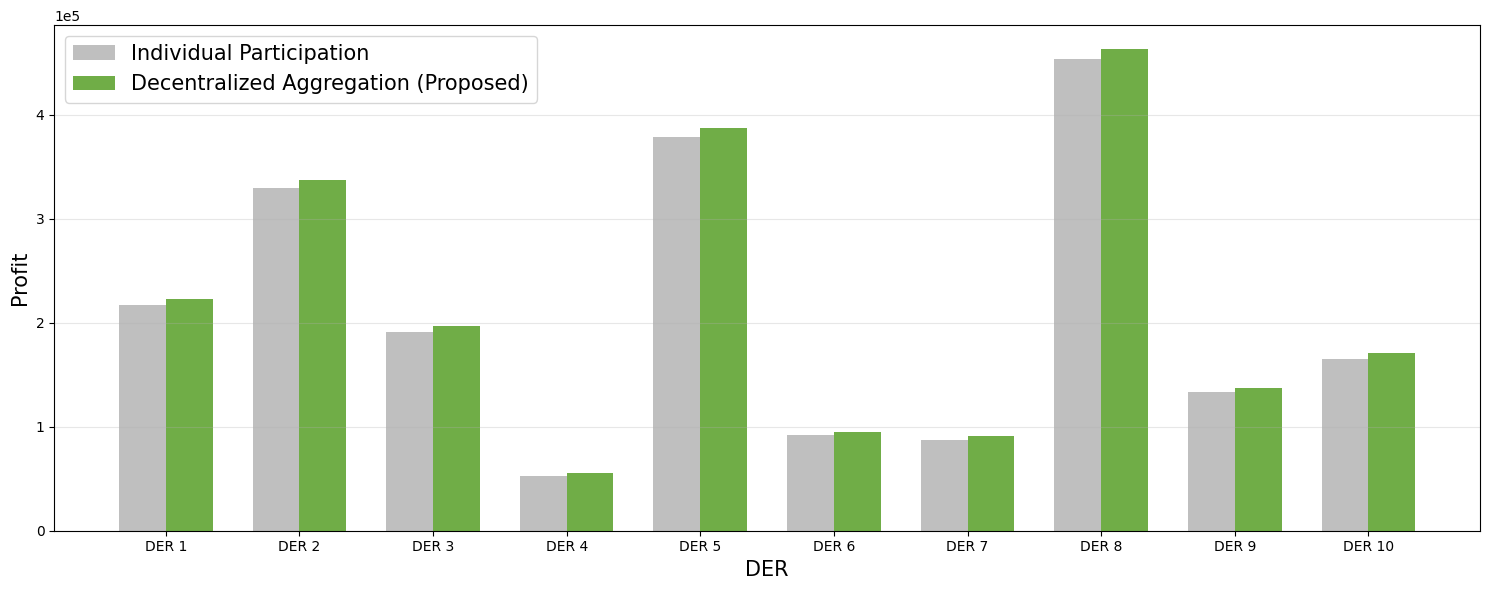

In [37]:
import matplotlib.pyplot as plt
import numpy as np

# 데이터
players = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
individual = [216866.58, 330127.01, 191156.99, 52994.14, 378807.62, 
              91957.31, 87309.68, 453336.51, 133010.81, 165113.37]
re_loss = [223360.89, 337422.80, 196953.84, 55403.00, 387577.79, 
           94831.35, 90897.02, 463156.90, 137552.89, 170913.86]

# 그래프 설정
x = np.arange(len(players))
width = 0.35

fig, ax = plt.subplots(figsize=(15, 6))

# 바 차트 생성
bars1 = ax.bar(x - width/2, individual, width, label='Individual Participation', color='#BFBFBF')
bars2 = ax.bar(x + width/2, re_loss, width, label='Decentralized Aggregation (Proposed)', color='#70AD47')

# 축 레이블 및 제목
ax.set_xlabel('DER', fontsize = 15)
ax.set_ylabel('Profit', fontsize = 15) # ($) 추가
ax.set_xticks(x)
ax.set_xticklabels([f'DER {i}' for i in players])
ax.legend(fontsize = 15)

# 격자 추가
ax.grid(True, alpha=0.3, axis='y')

# --- 이 부분을 추가하세요 ---
# y축 레이블을 과학적 표기법(scientific notation)으로 변경합니다.
# scilimits=(0,0)는 모든 숫자에 대해 과학적 표기법을 강제 적용합니다.
ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
# -------------------------

# 레이아웃 조정
plt.tight_layout()
plt.show()

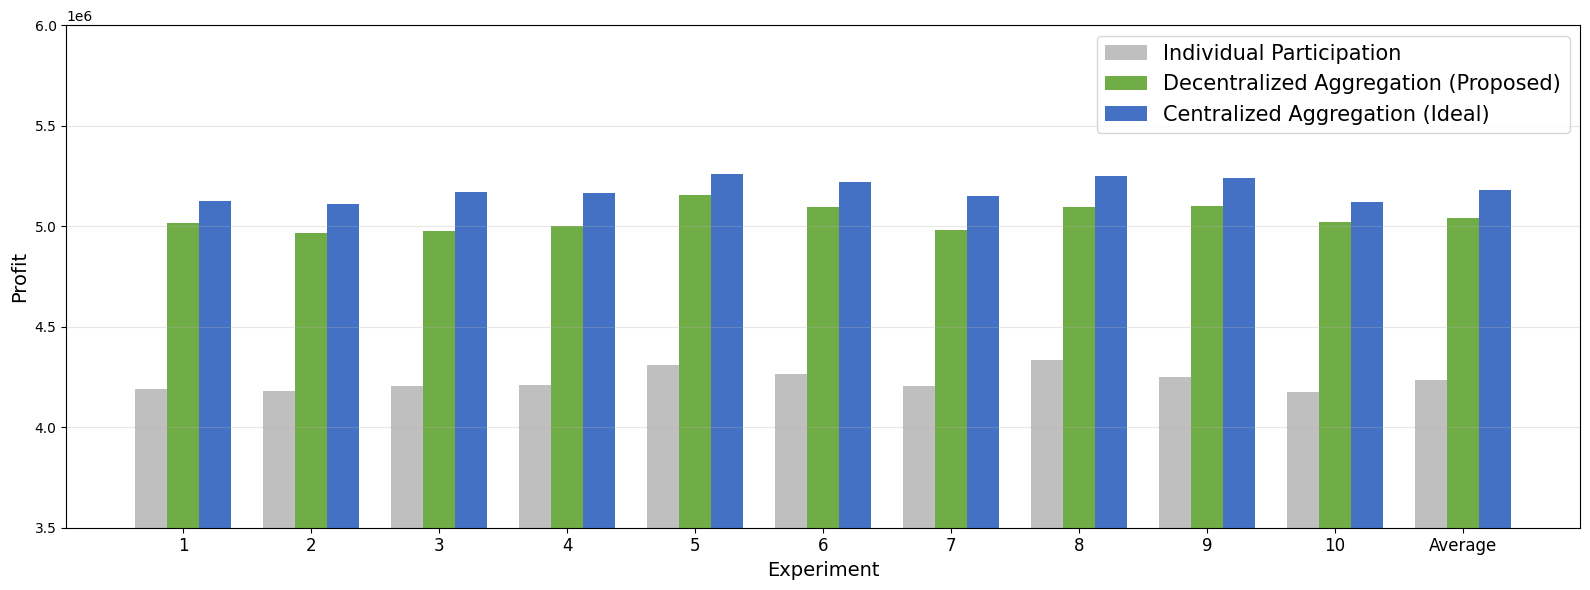

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# Provided data
seeds = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
individual = [4191840, 4179595, 4203089, 4210119, 4307675, 4266959, 4204982, 4336559, 4249098, 4177077]
decentralized = [5016014, 4967221, 4977120, 4999863, 5156704, 5094140, 4978965, 5095049, 5100348, 5022855]
centralized = [5127532, 5109052, 5170583, 5165589, 5258677, 5217372, 5149085, 5248225, 5237931, 5118401]


# --- 1. Calculate and append the average values ---
# Calculate the average for each list
avg_individual = np.mean(individual)
avg_decentralized = np.mean(decentralized)
avg_centralized = np.mean(centralized)

# Append the averages to the end of the original data lists
individual_with_avg = individual + [avg_individual]
decentralized_with_avg = decentralized + [avg_decentralized]
centralized_with_avg = centralized + [avg_centralized]

# --- 2. Update the x-axis labels ---
# Add 'Average' as the last label on the x-axis
seeds_with_avg_label = [str(s) for s in seeds] + ['Average']


# --- 3. Plotting ---
# Set the positions for the bars (now 11 positions)
x = np.arange(len(seeds_with_avg_label))
width = 0.25

fig, ax = plt.subplots(figsize=(16, 6))

# Plot the bars for each category using the new extended data
rects1 = ax.bar(x - width, individual_with_avg, width, label='Individual Participation', color='#BFBFBF')
rects2 = ax.bar(x, decentralized_with_avg, width, label='Decentralized Aggregation (Proposed)', color='#70AD47')
rects3 = ax.bar(x + width, centralized_with_avg, width, label='Centralized Aggregation (Ideal)', color='#4471C4')

# # --- 4. Add a black edge to the average bars to make them stand out ---
# for i in range(3):
#     bar_group = [rects1, rects2, rects3]
#     bar_group[i][-1].set_edgecolor('black')
#     bar_group[i][-1].set_linewidth(1.5)

# Add text for labels, title and axes ticks
ax.set_ylabel('Profit', fontsize=14)
ax.set_ylim(3500000, 6000000)
ax.set_xlabel('Experiment', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(seeds_with_avg_label, fontsize=12) # Use the new labels
ax.legend(fontsize=15)

ax.grid(axis='y', alpha=0.3)
fig.tight_layout()
plt.show()

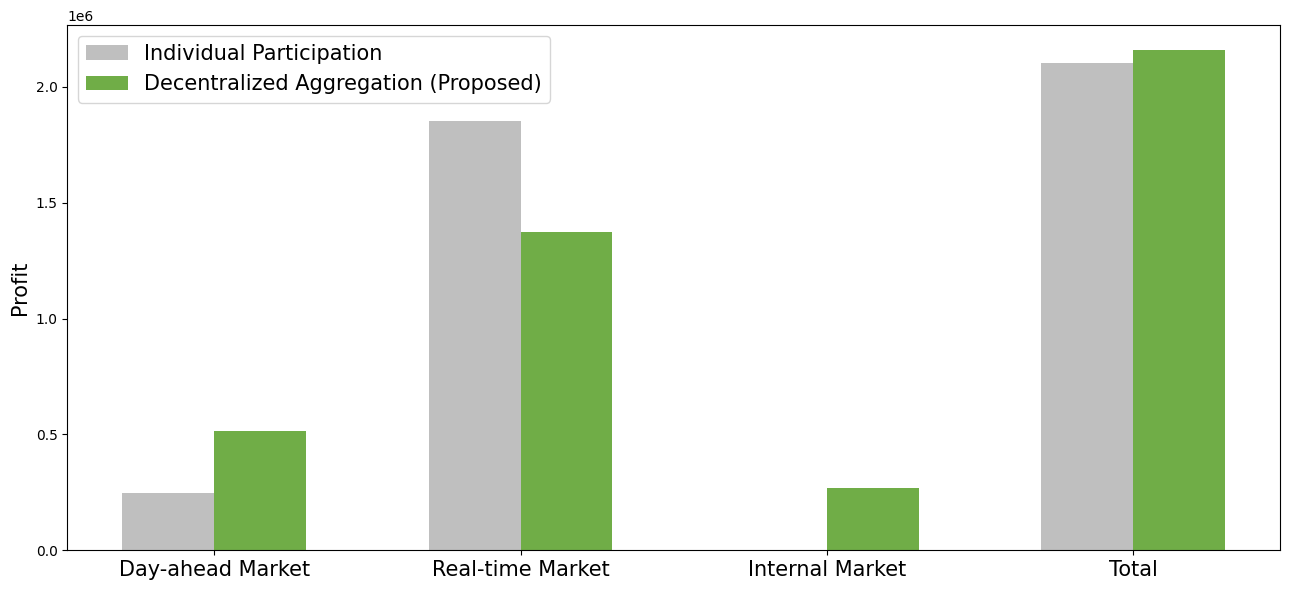

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# 1. 데이터 정의
markets = ['Day-ahead Market', 'Real-time Market', 'Internal Market', 'Total']
individual_profits = [247436.87, 1853243.15, 0, 2100680.01] # '-'는 0으로 처리
decentralized_profits = [515098.35, 1372764.45, 270207.55, 2158070.35]

# 2. 그래프 생성 준비
x = np.arange(len(markets))  # x축 market 위치
width = 0.3  # 막대 너비
fig, ax = plt.subplots(figsize=(13, 6))

# 3. 막대 그래프 그리기
rects1 = ax.bar(x - width/2, individual_profits, width, label='Individual Participation', color='#BFBFBF')
rects2 = ax.bar(x + width/2, decentralized_profits, width, label='Decentralized Aggregation (Proposed)', color='#70AD47')

# 4. 레이블, 제목, 범례 등 설정
ax.set_ylabel('Profit', fontsize=15)
ax.set_xticks(x)
ax.set_xticklabels(markets, fontsize=15)
ax.legend(fontsize = 15)

fig.tight_layout()
plt.show()

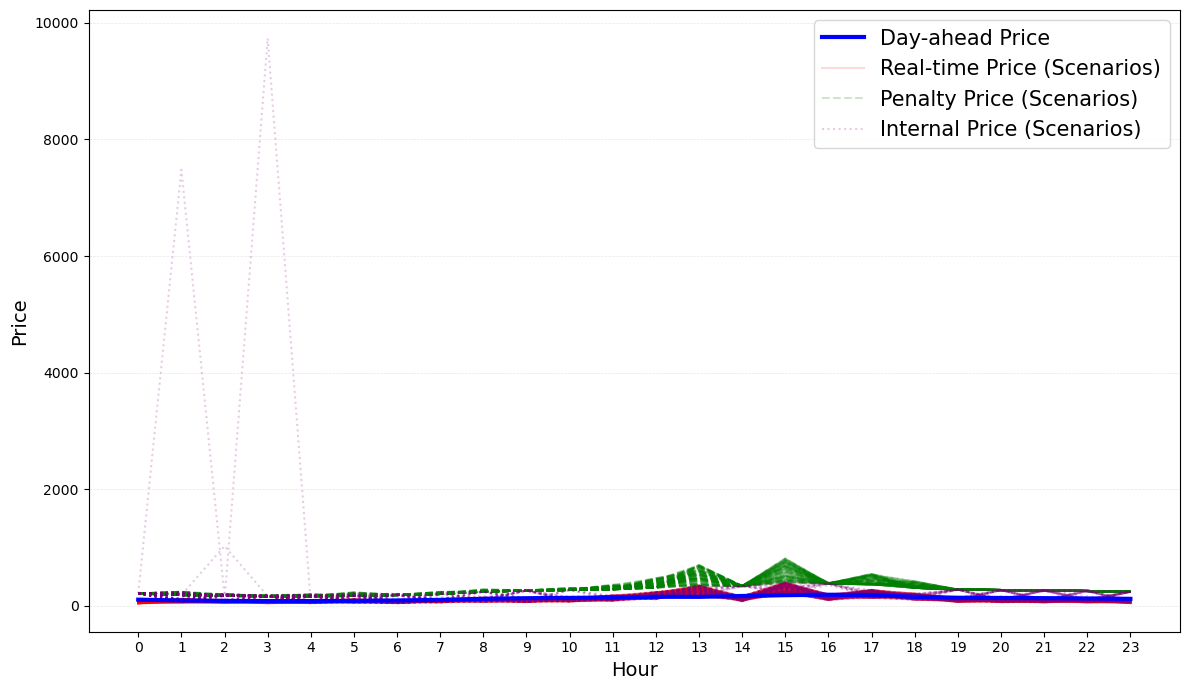

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

# --- 1. CSV 파일 불러오기 ---
try:
    filename = f'./data/optimization_results_{SEED}.csv'
    df = pd.read_csv(filename)

    # --- 2. 데이터 추출 ---
    p_da_data = df[['t', 'P_DA']].drop_duplicates().sort_values('t')

    # --- 3. 그래프 그리기 ---
    plt.figure(figsize=(12, 7))

    # P_DA (Day-ahead Price) 플롯
    plt.plot(p_da_data['t'], p_da_data['P_DA'], linestyle='-', color='blue', label='Day-ahead Price', linewidth=3, zorder=10)

    # P_RT (Real-time Price) 시나리오 플롯
    scenarios = df['s'].unique()
    for i, s in enumerate(scenarios):
        scenario_data = df[df['s'] == s]
        if i == 0:
            plt.plot(scenario_data['t'], scenario_data['P_RT'], linestyle='-', color='red', alpha=0.15, label='Real-time Price (Scenarios)')
        else:
            plt.plot(scenario_data['t'], scenario_data['P_RT'], linestyle='-', color='red', alpha=0.15)

    # P_PN (Penalty Price) 시나리오 플롯
    for i, s in enumerate(scenarios):
        scenario_data = df[df['s'] == s]
        if i == 0:
            plt.plot(scenario_data['t'], scenario_data['P_PN'], linestyle='--', color='green', alpha=0.2, label='Penalty Price (Scenarios)')
        else:
            plt.plot(scenario_data['t'], scenario_data['P_PN'], linestyle='--', color='green', alpha=0.2)

    # --- 💡 P_IN (Internal Price) 시나리오 플롯 추가 ---
    for i, s in enumerate(scenarios):
        scenario_data = df[df['s'] == s]
        if i == 0:
            plt.plot(scenario_data['t'], scenario_data['P_IN'], linestyle=':', color='purple', alpha=0.2, label='Internal Price (Scenarios)')
        else:
            plt.plot(scenario_data['t'], scenario_data['P_IN'], linestyle=':', color='purple', alpha=0.2)
    # --- P_IN 플롯 추가 끝 ---

    # --- 4. 그래프 꾸미기 ---
    plt.xlabel('Hour', fontsize=14)
    plt.ylabel('Price', fontsize=14)
    plt.grid(True, which='both', linestyle='--', linewidth=0.5, axis='y', alpha=0.3)
    plt.xticks(ticks=range(0, 24))
    plt.legend(fontsize=15)
    plt.tight_layout()

    # --- 5. 그래프 보여주기 ---
    plt.show()

except FileNotFoundError:
    print(f"오류: '{filename}' 파일을 찾을 수 없습니다.")
    print("스크립트와 같은 폴더에 CSV 파일이 있는지 확인해주세요.")
except Exception as e:
    print(f"오류가 발생했습니다: {e}")

총 100개 시나리오 중 8개를 삭제했습니다.
플롯에 표시될 시나리오 수: 92개


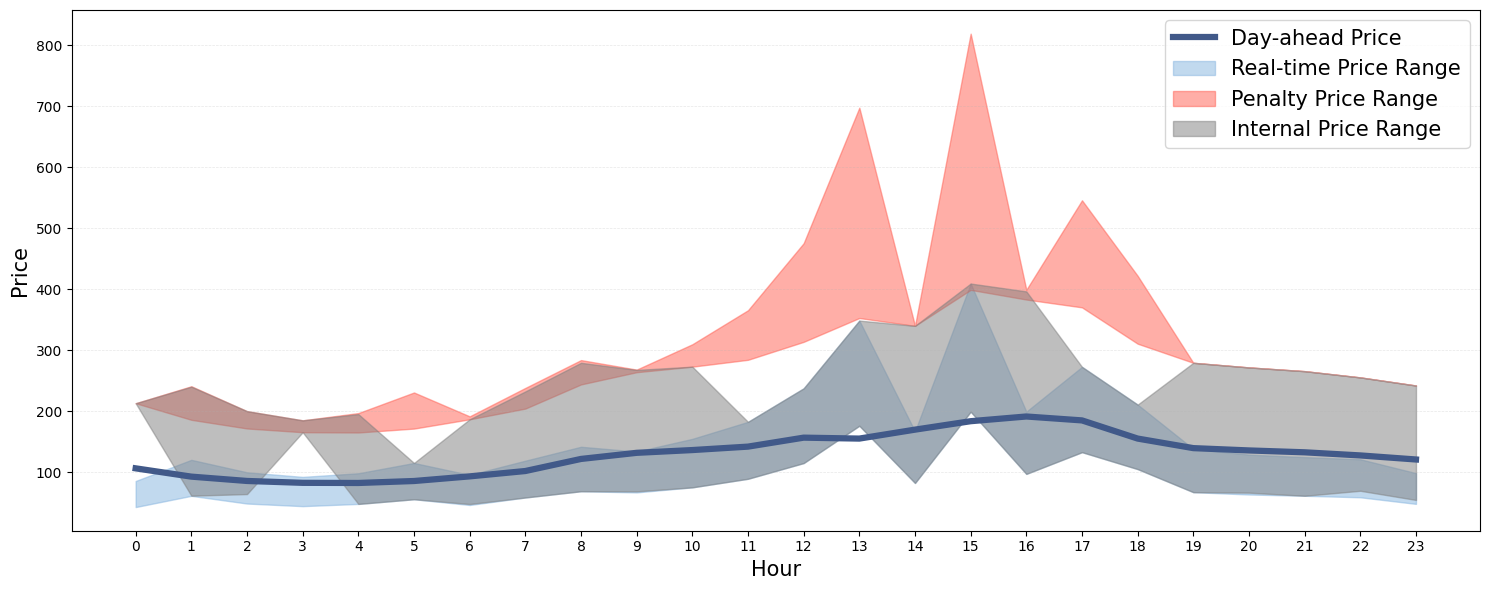

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# --- 1. CSV 파일 불러오기 ---
try:
    filename = './data/optimization_results_3.csv'
    df = pd.read_csv(filename)

    # --- 2. 조건에 맞지 않는 시나리오 필터링 ---
    original_scenario_count = len(df['s'].unique())
    if 'P_IN' not in df.columns and 'Internal_Price' in df.columns:
        df.rename(columns={'Internal_Price': 'P_IN'}, inplace=True)
    df['min_bound'] = df[['P_DA', 'P_RT', 'P_PN']].min(axis=1)
    df['max_bound'] = df[['P_DA', 'P_RT', 'P_PN']].max(axis=1)
    out_of_bounds_rows = df[(df['P_IN'] < df['min_bound'] - 1) | (df['P_IN'] > df['max_bound'] + 1)]
    scenarios_to_remove = out_of_bounds_rows['s'].unique()
    filtered_df = df[~df['s'].isin(scenarios_to_remove)]
    filtered_scenario_count = len(filtered_df['s'].unique())
    print(f"총 {original_scenario_count}개 시나리오 중 {len(scenarios_to_remove)}개를 삭제했습니다.")
    print(f"플롯에 표시될 시나리오 수: {filtered_scenario_count}개")

    # --- 3. 데이터 추출 ---
    p_da_data = filtered_df[['t', 'P_DA']].drop_duplicates().sort_values('t')

    # --- 4. 그래프 그리기 ---
    plt.figure(figsize=(15, 6))

    # P_DA 플롯
    plt.plot(p_da_data['t'], p_da_data['P_DA'],
             linestyle='-', color='#415989', label='Day-ahead Price', linewidth=4.5, zorder=10)

    # P_RT의 min/max 범위 색칠
    prt_range = filtered_df.groupby('t')['P_RT'].agg(['min', 'max'])
    plt.fill_between(prt_range.index, prt_range['min'], prt_range['max'],
                     color='#85B4DF',
                     alpha=0.5,
                     label='Real-time Price Range')

    # P_PN의 min/max 범위 색칠
    ppn_range = filtered_df.groupby('t')['P_PN'].agg(['min', 'max'])
    plt.fill_between(ppn_range.index, ppn_range['min'], ppn_range['max'],
                     color='#FF5E51',
                     alpha=0.5,
                     label='Penalty Price Range')

    # --- 💡 P_IN의 min/max 범위를 계산하고 색칠하기 ---
    pin_range = filtered_df.groupby('t')['P_IN'].agg(['min', 'max'])
    plt.fill_between(pin_range.index, pin_range['min'], pin_range['max'],
                     color='#7F7F7F',
                     alpha=0.5,
                     label='Internal Price Range')
    # --- P_IN 로직 변경 끝 ---


    # --- 5. 그래프 꾸미기 ---
    plt.xlabel('Hour', fontsize=15)
    plt.ylabel('Price', fontsize=15)
    plt.grid(True, which='both', linestyle='--', linewidth=0.5, axis='y', alpha=0.3)
    plt.xticks(ticks=range(0, 24))
    plt.legend(fontsize=15)
    plt.tight_layout()

    # --- 6. 그래프 보여주기 ---
    plt.show()

except FileNotFoundError:
    print(f"오류: '{filename}' 파일을 찾을 수 없습니다.")
    print("스크립트와 같은 폴더에 CSV 파일이 있는지 확인해주세요.")
except Exception as e:
    print(f"오류가 발생했습니다: {e}")

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# --- 1. CSV 파일 불러오기 ---
try:
    filename = f'./optimization_results_{SEED}.csv'
    df = pd.read_csv(filename)

    # --- 2. 조건에 맞지 않는 시나리오 필터링 ---
    original_scenario_count = len(df['s'].unique())
    if 'P_IN' not in df.columns and 'Internal_Price' in df.columns:
        df.rename(columns={'Internal_Price': 'P_IN'}, inplace=True)
    df['min_bound'] = df[['P_DA', 'P_RT', 'P_PN']].min(axis=1)
    df['max_bound'] = df[['P_DA', 'P_RT', 'P_PN']].max(axis=1)
    out_of_bounds_rows = df[(df['P_IN'] < df['min_bound'] - 1) | (df['P_IN'] > df['max_bound'] + 1)]
    scenarios_to_remove = out_of_bounds_rows['s'].unique()
    filtered_df = df[~df['s'].isin(scenarios_to_remove)]
    filtered_scenario_count = len(filtered_df['s'].unique())
    print(f"총 {original_scenario_count}개 시나리오 중 {len(scenarios_to_remove)}개를 삭제했습니다.")
    print(f"플롯에 표시될 시나리오 수: {filtered_scenario_count}개")

    # --- 3. 데이터 추출 ---
    p_da_data = filtered_df[['t', 'P_DA']].drop_duplicates().sort_values('t')

    # --- 4. 그래프 그리기 ---
    plt.figure(figsize=(15, 6))

    # P_DA 플롯
    plt.plot(p_da_data['t'], p_da_data['P_DA'],
             linestyle='-', color='#415989', label='Day-ahead Price', linewidth=4.5, zorder=10)

    # P_RT의 min/max 범위 색칠
    prt_range = filtered_df.groupby('t')['P_RT'].agg(['min', 'max'])
    plt.fill_between(prt_range.index, prt_range['min'], prt_range['max'],
                     color='#85B4DF',
                     alpha=0.5,
                     label='Real-time Price Range')
    # --- 💡 P_RT 테두리 추가 ---
    plt.plot(prt_range.index, prt_range['min'], color='#85B4DF', linewidth=1.5)
    plt.plot(prt_range.index, prt_range['max'], color='#85B4DF', linewidth=1.5)


    # P_PN의 min/max 범위 색칠
    ppn_range = filtered_df.groupby('t')['P_PN'].agg(['min', 'max'])
    plt.fill_between(ppn_range.index, ppn_range['min'], ppn_range['max'],
                     color='#FF5E51',
                     alpha=0.5,
                     label='Penalty Price Range', zorder=1)
    # --- 💡 P_PN 테두리 추가 ---
    plt.plot(ppn_range.index, ppn_range['min'], color='#FF5E51', linewidth=1.5)
    plt.plot(ppn_range.index, ppn_range['max'], color='#FF5E51', linewidth=1.5)


    # P_IN의 min/max 범위 색칠
    pin_range = filtered_df.groupby('t')['P_IN'].agg(['min', 'max'])
    plt.fill_between(pin_range.index, pin_range['min'], pin_range['max'],
                     color='#7F7F7F',
                     alpha=0.5,
                     label='Internal Price Range', zorder=2)

    # --- 5. 그래프 꾸미기 ---
    plt.xlabel('Hour', fontsize=15)
    plt.ylabel('Price', fontsize=15)
    plt.grid(True, which='both', linestyle='--', linewidth=0.5, axis='y', alpha=0.3)
    plt.xticks(ticks=range(0, 24))
    plt.legend(fontsize=15)
    plt.tight_layout()

    # --- 6. 그래프 보여주기 ---
    plt.show()

except FileNotFoundError:
    print(f"오류: '{filename}' 파일을 찾을 수 없습니다.")
    print("스크립트와 같은 폴더에 CSV 파일이 있는지 확인해주세요.")
except Exception as e:
    print(f"오류가 발생했습니다: {e}")

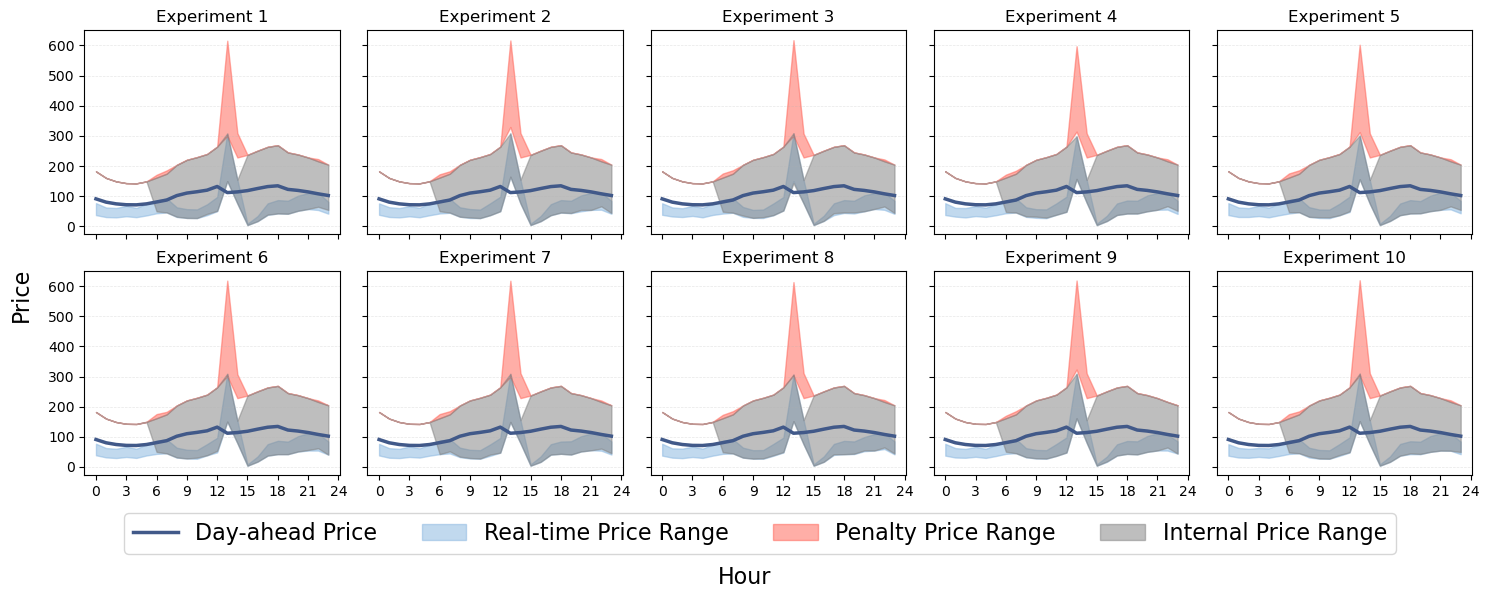

In [30]:
import pandas as pd
import matplotlib.pyplot as plt

# --- 1. 그래프 그리기 준비 ---
fig, axes = plt.subplots(2, 5, figsize=(15, 6), sharex=True, sharey=True)

# --- 2. 10개 파일에 대해 반복하여 플롯 그리기 ---
for i in range(1, 11):
    row = (i - 1) // 5
    col = (i - 1) % 5
    ax = axes[row, col]

    try:
        filename = f'./optimization_results_{i}.csv'
        df = pd.read_csv(filename)

        # --- 데이터 필터링 ---
        if 'P_IN' not in df.columns and 'Internal_Price' in df.columns:
            df.rename(columns={'Internal_Price': 'P_IN'}, inplace=True)
        df['min_bound'] = df[['P_DA', 'P_RT', 'P_PN']].min(axis=1)
        df['max_bound'] = df[['P_DA', 'P_RT', 'P_PN']].max(axis=1)
        out_of_bounds_rows = df[(df['P_IN'] < df['min_bound'] - 1) | (df['P_IN'] > df['max_bound'] + 1)]
        scenarios_to_remove = out_of_bounds_rows['s'].unique()
        filtered_df = df[~df['s'].isin(scenarios_to_remove)]

        # --- 각 서브플롯에 그래프 그리기 ---
        p_da_data = filtered_df[['t', 'P_DA']].drop_duplicates().sort_values('t')
        ax.plot(p_da_data['t'], p_da_data['P_DA'],
                linestyle='-', color='#415989', label='Day-ahead Price', linewidth=2.5, zorder=10)

        prt_range = filtered_df.groupby('t')['P_RT'].agg(['min', 'max'])
        ax.fill_between(prt_range.index, prt_range['min'], prt_range['max'],
                        color='#85B4DF', alpha=0.5, label='Real-time Price Range')

        ppn_range = filtered_df.groupby('t')['P_PN'].agg(['min', 'max'])
        ax.fill_between(ppn_range.index, ppn_range['min'], ppn_range['max'],
                        color='#FF5E51', alpha=0.5, label='Penalty Price Range')

        pin_range = filtered_df.groupby('t')['P_IN'].agg(['min', 'max'])
        ax.fill_between(pin_range.index, pin_range['min'], pin_range['max'],
                        color='#7F7F7F', alpha=0.5, label='Internal Price Range')

        ax.set_title(f'Experiment {i}', fontsize=12)
        ax.grid(True, which='both', linestyle='--', linewidth=0.5, axis='y', alpha=0.3)
        ax.set_xticks(ticks=range(0, 25, 3))

    except FileNotFoundError:
        ax.text(0.5, 0.5, f'File {i} not found', ha='center', va='center')
        ax.set_title(f'Experiment {i}', fontsize=12, color='red')
    except Exception as e:
        ax.text(0.5, 0.5, f'Error plotting file {i}', ha='center', va='center')

# --- 3. 공통 레이블 및 범례 설정 ---
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=4, bbox_to_anchor=(0.51, 0.05), fontsize=16) # y위치를 약간 조정

fig.supxlabel('Hour', fontsize=16)
fig.supylabel('Price', fontsize=16, x=0.01)

# --- 4. 레이아웃 조정 및 그래프 보여주기 ---
plt.tight_layout()
# 💡 bottom 값을 0.15에서 0.2로 늘려 하단 여백 확보
plt.subplots_adjust(bottom=0.2) 
plt.show()

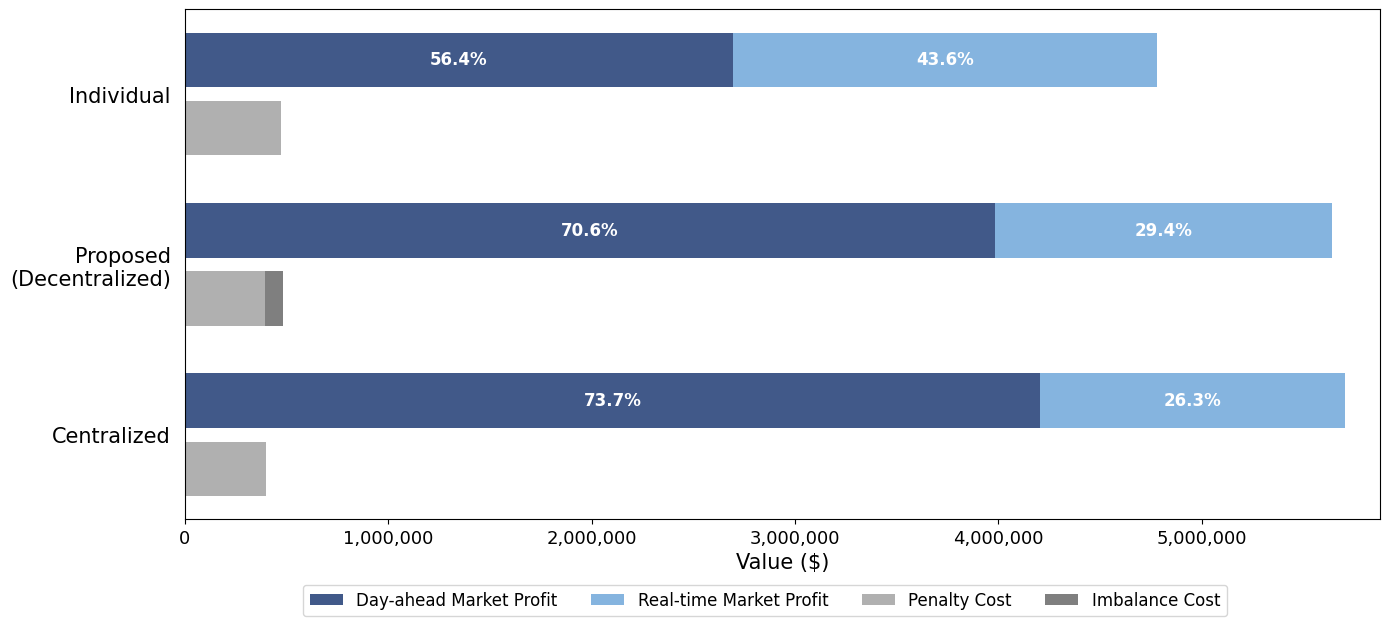

In [26]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Patch

# 1. Define Data
# --- 데이터 구조 정의 ---
# 6개의 막대에 대한 데이터 (순서가 중요합니다)
# 순서: 1.Indiv(Profit), 2.Indiv(Penalty), 3.Prop(Profit), 4.Prop(Penalty), 5.Cent(Profit), 6.Cent(Penalty)
data = {
    'Day-ahead Market': [
        2695474.68,  # 1. Indiv. Profit
        471062,       # 2. Indiv. Penalty
        3981218,      # 3. Prop. Profit
        392444,       # 4. Prop. Penalty
        4204554,      # 5. Centralized Profit
        398644        # 6. Centralized Penalty
    ],
    'Real-time Market': [
        2083263.230,  # 1. Indiv. Profit
        0,            # 2. Indiv. Penalty
        1660373,      # 3. Prop. Profit
        0,        # 4. Prop. Penalty
        1500000,      # 5. Centralized Profit
        0             # 6. Centralized Penalty
    ],
    'Imbalance Cost': [
        0,            # 1. Indiv. Profit (Imbalance Cost 없음)
        0,       # 2. Indiv. Imbalance Cost (가정된 값)
        0,            # 3. Prop. Profit (Imbalance Cost 없음)
        92443,        # 4. Prop. Imbalance Cost (가정된 값)
        0,            # 5. Centralized Profit (Imbalance Cost 없음)
        0         # 6. Centralized Imbalance Cost (가정된 값)
    ]
}
# DataFrame을 사용하여 총합(totals) 계산 (이제 3개 요소를 포함)
df_combined = pd.DataFrame(data)
totals = df_combined.sum(axis=1).values

# --- Y축 위치 및 라벨 설정 (핵심) ---
y_positions = [0, 1,  2.5, 3.5,  5.0, 6.0] 
bar_height = 0.8 

y_tick_labels = ['Individual', 'Proposed\n(Decentralized)', 'Centralized']
y_tick_positions = [
    (y_positions[0] + y_positions[1]) / 2, 
    (y_positions[2] + y_positions[3]) / 2, 
    (y_positions[4] + y_positions[5]) / 2  
]

# --- 색상 정의 ---
markets = ['Day-ahead Market', 'Real-time Market', 'Imbalance Cost']
profit_colors = ['#415989', '#85B4DF'] 
penalty_color = '#B0B0B0'
imbalance_color = '#7F7F7F' # [!! 신규 !!] 연한 회색

# 2. Create Plot
fig, ax = plt.subplots(figsize=(14, 7)) 

# 누적 막대 그래프 그리기
# 1. Day-ahead Market 그리기
da_values = df_combined['Day-ahead Market'].values
da_colors = [profit_colors[0], penalty_color, 
             profit_colors[0], penalty_color, 
             profit_colors[0], penalty_color]
bars_da = ax.barh(y_positions, da_values, height=bar_height, label='Day-ahead Market', color=da_colors)

# 2. Real-time Market 그리기 (DA Market 오른쪽에 누적)
rt_values = df_combined['Real-time Market'].values
rt_colors = [profit_colors[1], penalty_color, 
             profit_colors[1], penalty_color, 
             profit_colors[1], penalty_color]
bars_rt = ax.barh(y_positions, rt_values, left=da_values, height=bar_height, label='Real-time Market', color=rt_colors)

# 3. [!! 신규 !!] Imbalance Cost 그리기 (RT Market 오른쪽에 누적)
imbalance_values = df_combined['Imbalance Cost'].values
imbalance_colors = [imbalance_color] * 6 
bars_imbalance = ax.barh(y_positions, imbalance_values, left=da_values + rt_values, 
                         height=bar_height, label='Imbalance Cost', color=imbalance_colors)

# 4. 퍼센트 텍스트 추가 (DA와 RT의 Profit 바에만)
# Day-ahead Market 텍스트
for i, bar in enumerate(bars_da):
    width = bar.get_width()
    if width > 0 and totals[i] > 0:
        percentage = width / totals[i] * 100
        if percentage > 4 and i % 2 == 0: 
            ax.text(bar.get_x() + width / 2, bar.get_y() + bar.get_height() / 2,
                    f'{percentage:.1f}%', ha='center', va='center', color='white', fontweight='bold', fontsize=12)

# Real-time Market 텍스트
for i, bar in enumerate(bars_rt):
    width = bar.get_width()
    if width > 0 and totals[i] > 0:
        percentage = width / totals[i] * 100
        if percentage > 4 and i % 2 == 0:
            ax.text(bar.get_x() + width / 2, bar.get_y() + bar.get_height() / 2,
                    f'{percentage:.1f}%', ha='center', va='center', color='white', fontweight='bold', fontsize=12)

# 5. Style the plot
ax.set_xlabel('Value ($)', fontsize=15)
ax.tick_params(axis='x', labelsize=13)

# --- [!! 수정 !!] X축 오른쪽에 여백 추가 ---
# 가장 긴 막대를 기준으로 15%의 오른쪽 여백을 줍니다.
ax.set_xlim(right=max(totals) * 1.03) 
# ----------------------------------------

# --- Y축 스타일링 ---
ax.set_yticks(y_tick_positions)      
ax.set_yticklabels(y_tick_labels)    
ax.tick_params(axis='y', labelsize=15, length=0, pad=10) 
ax.invert_yaxis() 

# X축 포맷터
ax.get_xaxis().set_major_formatter(
    plt.FuncFormatter(lambda x, p: format(int(x), ','))
)

# --- 범례 수정 ---
legend_elements = [
    Patch(facecolor=profit_colors[0], label='Day-ahead Market Profit'),
    Patch(facecolor=profit_colors[1], label='Real-time Market Profit'),
    Patch(facecolor=penalty_color, label='Penalty Cost'), # 라벨 수정
    Patch(facecolor=imbalance_color, label='Imbalance Cost') # [!! 신규 !!]
]
fig.legend(handles=legend_elements, loc='lower center', ncol=4, # ncol=4로 변경
           bbox_to_anchor=(0.55, 0.1), fontsize=12, title_fontsize=14)

# 레이아웃 조절
plt.tight_layout()
plt.subplots_adjust(bottom=0.25)
plt.show()

총 100개 시나리오의 평균값을 사용합니다.


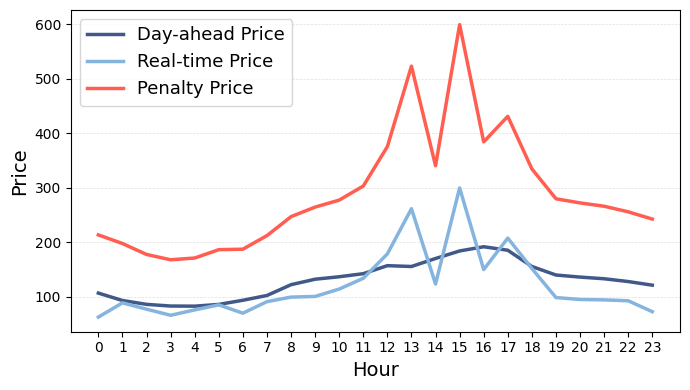

In [28]:
import pandas as pd
import matplotlib.pyplot as plt

# === 1) 데이터 불러오기 ===
filename = './data/optimization_results_2.csv'
df = pd.read_csv(filename)

# 컬럼 표준화 (있을 때만 변경)
rename_map = {
    'DayAheadPrice':'P_DA', 'RealTimePrice':'P_RT', 'PenaltyPrice':'P_PN',
    'timestep':'t', 'scenario':'s'
}
for k, v in rename_map.items():
    if k in df.columns and v not in df.columns:
        df.rename(columns={k: v}, inplace=True)

# === 2) 시나리오 평균으로 집계 ===
df_avg = (df.groupby('t', as_index=False)[['P_DA','P_RT','P_PN']]
            .mean()
            .sort_values('t'))

print(f"총 {df['s'].nunique()}개 시나리오의 평균값을 사용합니다.")

# === 3) 플롯 ===
plt.figure(figsize=(7, 4))
plt.plot(df_avg['t'], df_avg['P_DA'], label='Day-ahead Price', color='#415989', linewidth=2.5)
plt.plot(df_avg['t'], df_avg['P_RT'], label='Real-time Price', color='#85B4DF', linewidth=2.5)
plt.plot(df_avg['t'], df_avg['P_PN'], label='Penalty Price', color='#FF5E51', linewidth=2.5)

plt.xlabel('Hour', fontsize=14)
plt.ylabel('Price', fontsize=14)
plt.grid(True, axis='y', linestyle='--', linewidth=0.5, alpha=0.4)

try:
    plt.xticks(range(int(df_avg['t'].min()), int(df_avg['t'].max())+1))
except:
    pass

plt.legend(loc='upper left', fontsize=13)
plt.tight_layout()
plt.show()

총 100개 시나리오를 평균/범위로 집계했습니다.


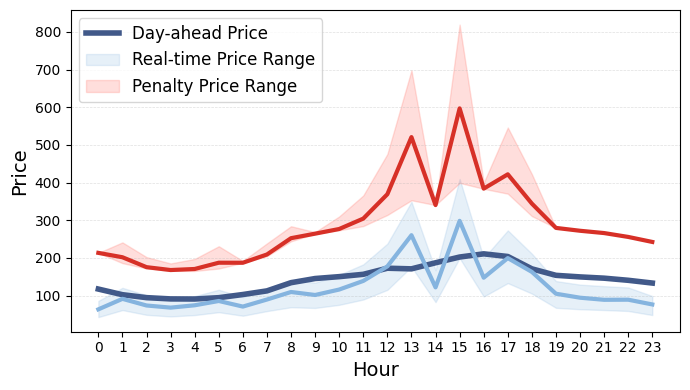

In [70]:
import pandas as pd
import matplotlib.pyplot as plt

# === 1) 데이터 불러오기 ===
filename = './data/optimization_results_3.csv'
df = pd.read_csv(filename)

# 컬럼 표준화 (있을 때만 변경)
rename_map = {
    'DayAheadPrice':'P_DA', 'RealTimePrice':'P_RT', 'PenaltyPrice':'P_PN',
    'timestep':'t', 'scenario':'s'
}
for k, v in rename_map.items():
    if k in df.columns and v not in df.columns:
        df.rename(columns={k: v}, inplace=True)

# === 2) 평균, 최소, 최대 집계 ===
agg_df = df.groupby('t')[['P_DA','P_RT','P_PN']].agg(['mean','min','max'])
# 멀티인덱스 정리
agg_df.columns = ['_'.join(col) for col in agg_df.columns]
agg_df = agg_df.reset_index()

print(f"총 {df['s'].nunique()}개 시나리오를 평균/범위로 집계했습니다.")

# === 3) 플롯 ===
plt.figure(figsize=(7, 4))

# Day-ahead (확정적이라 min=max일 수 있음)
plt.plot(agg_df['t'], agg_df['P_DA_mean']*1.1, color='#415989', label='Day-ahead Price', linewidth=4)

# Real-time
plt.plot(agg_df['t'], agg_df['P_RT_mean'], color='#85B4DF', linewidth=3)
# plt.plot(agg_df['t'], agg_df['P_RT_mean'], color='#85B4DF', label='Real-time Price (avg)', linewidth=3)
plt.fill_between(agg_df['t'], agg_df['P_RT_min'], agg_df['P_RT_max'], color='#85B4DF', alpha=0.2, label='Real-time Price Range')

# Penalty
plt.plot(agg_df['t'], agg_df['P_PN_mean'], color='#D73027', linewidth=3)
# plt.plot(agg_df['t'], agg_df['P_PN_mean'], color='#D73027', label='Penalty Price (avg)', linewidth=3)
plt.fill_between(agg_df['t'], agg_df['P_PN_min'], agg_df['P_PN_max'], color='#FF5E51', alpha=0.2, label='Penalty Price Range')

# === 4) 그래프 꾸미기 ===
plt.xlabel('Hour', fontsize=14)
plt.ylabel('Price', fontsize=14)
plt.grid(True, axis='y', linestyle='--', linewidth=0.5, alpha=0.4)

try:
    plt.xticks(range(int(agg_df['t'].min()), int(agg_df['t'].max())+1))
except:
    pass

plt.legend(fontsize=12, loc='upper left')
plt.tight_layout()
plt.show()

/var/folders/2_/9m9qjphn0xs45xzpvf1hl0j00000gn/T/ipykernel_86770/1712459671.py:33: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df[ts_col]   = pd.to_datetime(df[ts_col], errors='coerce', infer_datetime_format=True)
/var/folders/2_/9m9qjphn0xs45xzpvf1hl0j00000gn/T/ipykernel_86770/1712459671.py:33: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[ts_col]   = pd.to_datetime(df[ts_col], errors='coerce', infer_datetime_format=True)
/var/folders/2_/9m9qjphn0xs45xzpvf1hl0j00000gn/T/ipykernel_86770/1712459671.py:33: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of i

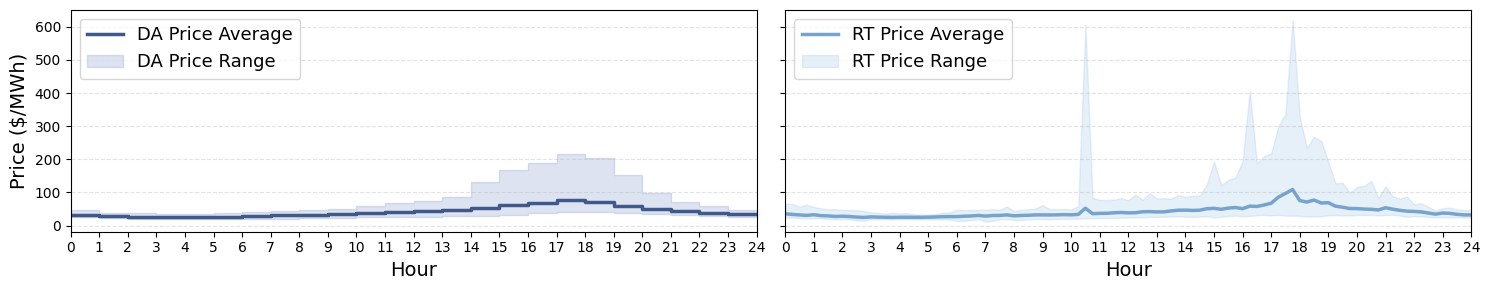

In [62]:
import pandas as pd
import matplotlib.pyplot as plt

# ------------ 설정 -------------
da_file = './data/OASIS_Day-Ahead_Market_Zonal_LBMP.csv'
rt_file = './data/OASIS_Real_Time_Commitment_Zonal_LBMP.csv'
TARGET_ZONE  = 'N.Y.C.'
TARGET_MONTH = 7
USE_STEP_FOR_DA = True  # DA를 계단(step) 라인으로 그릴지 여부
# --------------------------------

# 유틸: 후보 컬럼 찾기
def find_col(cols, cands, required=True, what=''):
    for c in cands:
        if c in cols:
            return c
    if required:
        raise KeyError(f"열을 찾을 수 없습니다({what}). 후보={cands} / 실제열={list(cols)}")
    return None

# 공통 로더 (ts_col 이름도 반환)
def load_and_prepare(path, price_cands, zone_cands, ts_cands):
    df = pd.read_csv(path)
    df.columns = df.columns.str.strip()

    ts_col    = find_col(df.columns, ts_cands,   what='타임스탬프')
    zone_col  = find_col(df.columns, zone_cands, what='존 이름')
    price_col = find_col(df.columns, price_cands, what='가격')

    # 기본 전처리
    df[zone_col] = df[zone_col].astype(str).str.strip()
    # 유연 파싱(형식 자동 인식)
    df[ts_col]   = pd.to_datetime(df[ts_col], errors='coerce', infer_datetime_format=True)
    df = df.dropna(subset=[ts_col])

    # 필터
    df = df[df[zone_col] == TARGET_ZONE].copy()
    df['Month'] = df[ts_col].dt.month
    df = df[df['Month'] == TARGET_MONTH].copy()

    # 파생
    df['Hour'] = df[ts_col].dt.hour
    df['Date'] = df[ts_col].dt.date
    return df, price_col, ts_col

# 집계 함수 (DA: 24시간 기준 평균/최소/최대)
def hourly_avg_minmax(df, price_col):
    pv = df.pivot_table(index='Hour', columns='Date', values=price_col, aggfunc='mean')
    out = pd.DataFrame({
        'Hour': pv.index,
        'avg' : pv.mean(axis=1),
        'min' : pv.min(axis=1),
        'max' : pv.max(axis=1),
    }).reset_index(drop=True)
    # 0~23 보장
    return out.set_index('Hour').reindex(range(24)).reset_index()

# ---- 후보 목록(DA/RT 파일용) ----
TS_CANDS_DA = ['Eastern Date Hour', 'Time Stamp', 'Timestamp', 'Time']
TS_CANDS_RT = ['RTC End Time Stamp', 'RT End Time Stamp',
               'Eastern Date Hour', 'Time Stamp', 'Timestamp', 'Time']
ZONE_CANDS  = ['Zone Name', 'Name', 'Zone']
PRICE_DA_CANDS = ['DAM Zonal LBMP', 'DAM Zonal Price', 'LBMP ($/MWHr)', 'LBMP']
PRICE_RT_CANDS = ['RT Commitment Zonal LBMP', 'RTC Zonal LBMP',
                  'Realtime Zonal LBMP', 'LBMP ($/MWHr)', 'LBMP']

# ---- 로드 ----
df_da, price_da, ts_da = load_and_prepare(da_file, PRICE_DA_CANDS, ZONE_CANDS, TS_CANDS_DA)
df_rt, price_rt, ts_rt = load_and_prepare(rt_file, PRICE_RT_CANDS, ZONE_CANDS, TS_CANDS_RT)

if df_da.empty: raise ValueError("Day-Ahead 7월 데이터가 없습니다.")
if df_rt.empty: raise ValueError("Real-Time 7월 데이터가 없습니다.")

# ---- 집계: DA(24시간) ----
da_hourly = hourly_avg_minmax(df_da, price_da)

# ---- 집계: RT(15분 = 96 슬롯) ----
# 15분 경계만 남기기
df_rt['Minute'] = df_rt[ts_rt].dt.minute
df_rt = df_rt[df_rt['Minute'].isin([0, 15, 30, 45])].copy()

# 슬롯 축 (0.00, 0.25, ..., 23.75)
df_rt['Slot'] = df_rt['Hour'] + df_rt['Minute'] / 60.0

# 날짜×슬롯 평균 → 슬롯별로 날짜 across 통계
rt_day_slot = df_rt.groupby(['Date', 'Slot'], as_index=False)[price_rt].mean()
pv_rt = rt_day_slot.pivot_table(index='Slot', columns='Date', values=price_rt, aggfunc='mean').sort_index()

rt_slot = pd.DataFrame({
    'Slot': pv_rt.index,
    'avg' : pv_rt.mean(axis=1),
    'min' : pv_rt.min(axis=1),
    'max' : pv_rt.max(axis=1),
}).reset_index(drop=True)

da_ext = da_hourly.copy()
last = da_ext.loc[da_ext['Hour'] == 23].iloc[0]
da_ext = pd.concat([
    da_ext,
    pd.DataFrame([{'Hour': 24, 'avg': last['avg'], 'min': last['min'], 'max': last['max']}])
], ignore_index=True)

last_rt = rt_slot.iloc[-1]
rt_ext = pd.concat(
    [rt_slot,
     pd.DataFrame([{'Slot': 24.0,
                    'avg': last_rt['avg'],
                    'min': last_rt['min'],
                    'max': last_rt['max']}])],
    ignore_index=True
)

# ---- 플롯(가로 2개, 공유 y축, x축 0~24 통일) ----
fig, (ax_da, ax_rt) = plt.subplots(1, 2, figsize=(15, 3), sharey=True)

x   = da_ext['Hour'].to_numpy()
avg = da_ext['avg'].to_numpy()
lo  = da_ext['min'].to_numpy()
hi  = da_ext['max'].to_numpy()

if USE_STEP_FOR_DA:
    ax_da.step(x, avg, where='post', linewidth=2.5, label='DA Price Average', color='#415989')
    ax_da.fill_between(x, lo, hi, step='post', alpha=0.2, label='DA Price Range', color='#5777BB')
else:
    ax_da.plot(x, avg, linewidth=2.2, label='Day-Ahead Price Average')
    ax_da.fill_between(x, lo, hi, alpha=0.28, label='Day-Ahead Price Range')

ax_da.set_xlabel('Hour', fontsize=14)
ax_da.set_ylabel('Price ($/MWh)', fontsize=14)
ax_da.grid(True, axis='y', linestyle='--', alpha=0.35)
ax_da.legend(loc='upper left', fontsize=13)
ax_da.set_xlim(0, 24)
ax_da.set_xticks(range(0, 25, 1))

# Real-Time (15분)
ax_rt.plot(rt_ext['Slot'], rt_ext['avg'], linewidth=2.5, label='RT Price Average', color='#76A4CC')
ax_rt.fill_between(rt_ext['Slot'], rt_ext['min'], rt_ext['max'], alpha=0.2, label='RT Price Range', color='#85B4DF')
ax_rt.set_xlabel('Hour', fontsize=14)
ax_rt.grid(True, axis='y', linestyle='--', alpha=0.35)
ax_rt.legend(loc='upper left', fontsize=13)
ax_rt.set_xlim(0, 24)
ax_rt.set_xticks(range(0, 25, 1))

plt.tight_layout()
plt.show()

C:\Users\jangseohyun\AppData\Local\Temp\ipykernel_24824\1161954583.py:15: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['datetime_beginning_ept'] = pd.to_datetime(df['datetime_beginning_ept'], errors='coerce')
C:\Users\jangseohyun\AppData\Local\Temp\ipykernel_24824\1161954583.py:15: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['datetime_beginning_ept'] = pd.to_datetime(df['datetime_beginning_ept'], errors='coerce')


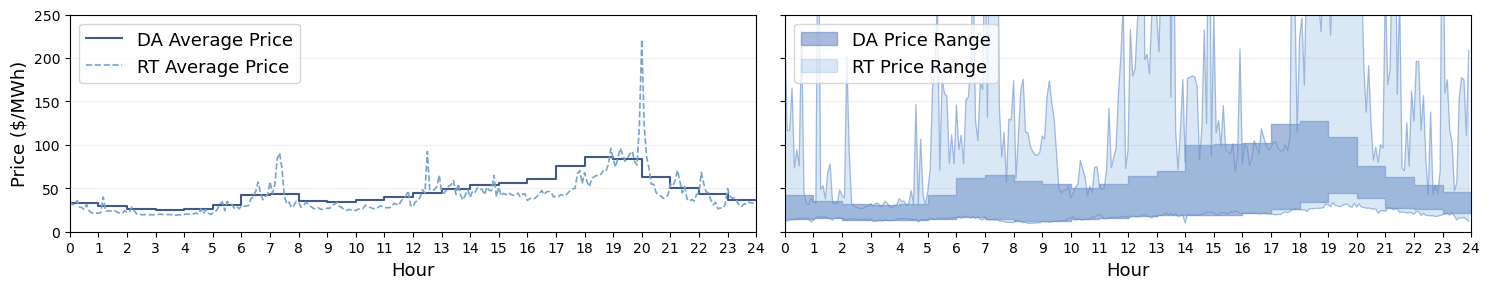

노드=PJM-RTO, 월=ALL
DA rows: 649 | RT rows: 7200


In [43]:
# %%
import pandas as pd
import matplotlib.pyplot as plt

# ================== 설정(원하면 바꾸세요) ==================
DA_FILE = './data/da_hrl_lmps.csv'
RT_FILE = './data/rt_fivemin_hrl_lmps.csv'
TARGET_NODE  = 'PJM-RTO'
TARGET_MONTH = None
USE_STEP_FOR_DA = True
# =========================================================

def load_pjm_csv(path, price_col):
    df = pd.read_csv(path)
    df['datetime_beginning_ept'] = pd.to_datetime(df['datetime_beginning_ept'], errors='coerce')
    df['pnode_name'] = df['pnode_name'].astype(str).str.strip()
    df = df[df['pnode_name'] == TARGET_NODE].dropna(subset=['datetime_beginning_ept']).copy()
    df[price_col] = pd.to_numeric(df[price_col], errors='coerce')
    if TARGET_MONTH is not None:
        df = df[df['datetime_beginning_ept'].dt.month == int(TARGET_MONTH)].copy()
    df['date'] = df['datetime_beginning_ept'].dt.date
    df['hour'] = df['datetime_beginning_ept'].dt.hour
    df['minute'] = df['datetime_beginning_ept'].dt.minute
    return df

da = load_pjm_csv(DA_FILE, 'system_energy_price_da')
rt = load_pjm_csv(RT_FILE, 'system_energy_price_rt')
if da.empty or rt.empty:
    raise ValueError("선택한 조건에서 DA 또는 RT 데이터가 비었습니다. TARGET_NODE/TARGET_MONTH를 확인하세요.")

# DA stats
da_pv = da.pivot_table(index='hour', columns='date', values='system_energy_price_da', aggfunc='mean')
da_hour_stats = pd.DataFrame({'hour': da_pv.index.values})
da_hour_stats['avg'] = pd.to_numeric(da_pv.mean(axis=1), errors='coerce').values
da_hour_stats['min'] = pd.to_numeric(da_pv.min(axis=1), errors='coerce').values
da_hour_stats['max'] = pd.to_numeric(da_pv.max(axis=1), errors='coerce').values
da_hour_stats = da_hour_stats.set_index('hour').reindex(range(24)).reset_index()
da_hour_stats[['avg','min','max']] = da_hour_stats[['avg','min','max']].ffill().bfill()

da_tail = da_hour_stats.iloc[-1].copy()
da_tail['hour'] = 24
da_hour_ext = pd.concat([da_hour_stats, pd.DataFrame([da_tail])], ignore_index=True)


# RT stats
rt['slot'] = rt['hour'] + rt['minute'] / 60.0
rt_pv = rt.pivot_table(index='slot', columns='date', values='system_energy_price_rt', aggfunc='mean').sort_index()
rt_slot_stats = pd.DataFrame({'slot': rt_pv.index.values})
rt_slot_stats['avg'] = pd.to_numeric(rt_pv.mean(axis=1), errors='coerce').values
rt_slot_stats['min'] = pd.to_numeric(rt_pv.min(axis=1), errors='coerce').values
rt_slot_stats['max'] = pd.to_numeric(rt_pv.max(axis=1), errors='coerce').values

# Convert to float arrays to avoid dtype issues in matplotlib
hx   = da_hour_ext['hour'].to_numpy(dtype=float)
havg = pd.to_numeric(da_hour_ext['avg'], errors='coerce').to_numpy(dtype=float)
hmin = pd.to_numeric(da_hour_ext['min'], errors='coerce').to_numpy(dtype=float)
hmax = pd.to_numeric(da_hour_ext['max'], errors='coerce').to_numpy(dtype=float)

sx = rt_slot_stats['slot'].to_numpy(dtype=float)
savg = pd.to_numeric(rt_slot_stats['avg'], errors='coerce').to_numpy(dtype=float)
smin = pd.to_numeric(rt_slot_stats['min'], errors='coerce').to_numpy(dtype=float)
smax = pd.to_numeric(rt_slot_stats['max'], errors='coerce').to_numpy(dtype=float)

# Plot
fig, (ax_avg, ax_rng) = plt.subplots(1, 2, figsize=(15, 3), sharey=True)

# 평균 비교
if USE_STEP_FOR_DA:
    ax_avg.step(hx, havg*1.2, where='post', linewidth=1.5, label='DA Average Price', color='#415989')
else:
    ax_avg.plot(hx, havg, linewidth=1.5, label='DA System Price (avg)')
ax_avg.plot(sx, savg, linewidth=1.2, linestyle='--', label='RT Average Price', color='#76A4CC')
ax_avg.set_xlabel('Hour', fontsize=13)
ax_avg.set_ylabel('Price ($/MWh)', fontsize=13)
ax_avg.grid(True, axis='y', alpha=0.2)
ax_avg.set_xlim(0, 24)
ax_avg.set_ylim(0,250)
ax_avg.set_xticks(range(0, 25, 1))
ax_avg.legend(loc='upper left', fontsize=13)

# 범위 비교
ax_rng.fill_between(hx, hmin, hmax, step='post', alpha=0.5, label='DA Price Range', color='#5777BB')
# ax_rng.plot(hx, hmin, linewidth=0.8, color='#415989')
# ax_rng.plot(hx, hmax, linewidth=0.8, color='#415989')

ax_rng.fill_between(sx, smin, smax, alpha=0.3, label='RT Price Range', color='#85B4DF')
ax_rng.plot(sx, smin, linewidth=0.8, color='#5777BB', alpha=0.4)
ax_rng.plot(sx, smax, linewidth=0.8, color='#5777BB', alpha=0.4)

ax_rng.set_xlabel('Hour', fontsize=13)
ax_rng.grid(True, axis='y', alpha=0.2)
ax_rng.set_xlim(0, 24)
ax_rng.set_xticks(range(0, 25, 1))
ax_rng.legend(loc='upper left', fontsize=13)

plt.tight_layout()
plt.show()

print(f"노드={TARGET_NODE}, 월={'ALL' if TARGET_MONTH is None else TARGET_MONTH}")
print("DA rows:", len(da), "| RT rows:", len(rt))


✅ 총 10개 파일을 불러왔습니다: 1033.csv, 1818.csv, 2502.csv, 2503.csv, 2634.csv, 2698.csv, 2816.csv, 545.csv, 665.csv, 690.csv
📊 데이터 Shape: I=10, T=24, S=50
✅ 시뮬레이션 초기화 완료: S=50, Randomness='high', Random Seed=1, M1=3679.70, M2=10215.24
   - 개별 K 값: [200. 200. 400. 600. 100. 600. 300. 200. 300. 200.]


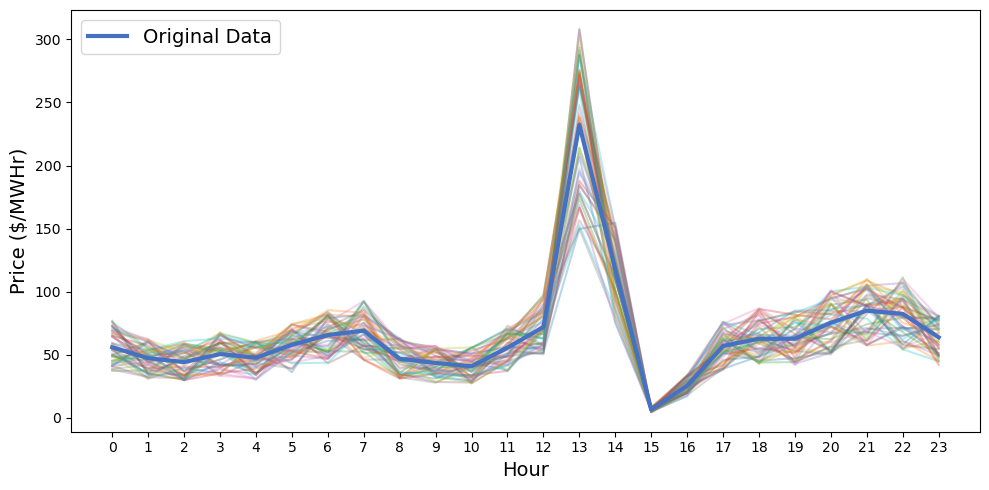

In [12]:
import os; import pandas as pd
pd.options.display.float_format = '{:.3f}'.format
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
import numpy as np; import matplotlib.pyplot as plt
import gurobipy as gp; from gurobipy import GRB
from itertools import product; from tqdm import tqdm
import importlib
import functions_utils; import functions_data
import functions_optimize; import functions_eval
importlib.reload(functions_data); importlib.reload(functions_optimize)
importlib.reload(functions_eval); importlib.reload(functions_utils)
from functions_utils import *; from functions_data import *
from functions_optimize import *; from functions_eval import *
import time

S = 50
LEVEL = "high"
SEED = 1

generation_data, I, T = load_generation_data(date_filter="2022-07-18")
R, P_RT, K, K0, _, _, CRATE, DRATE = load_parameters(I, T, generation_data, S, LEVEL, SEED)
P_DA, P_PN = load_price_data(P_RT)
INEFF = 0.9

plot_rt_scenarios(P_RT)


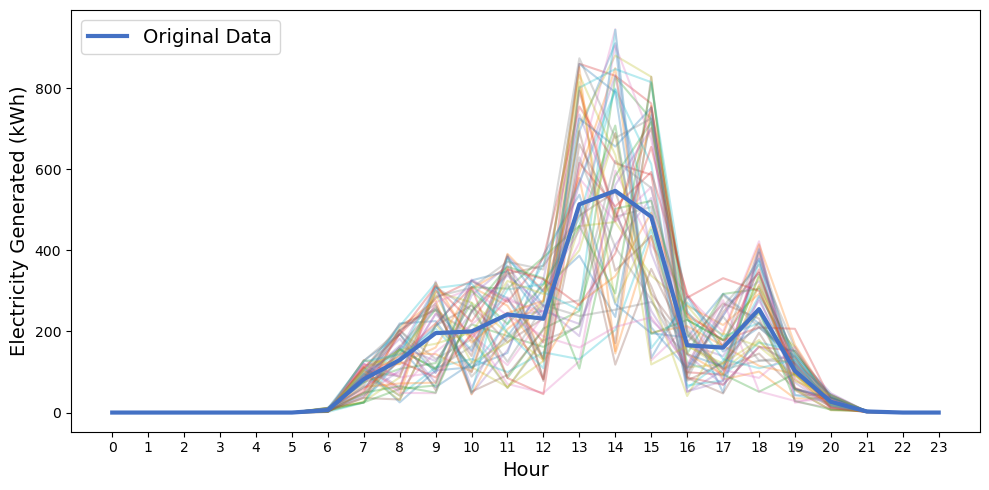

In [13]:
plot_scenarios_for_generator(R, 1)